# Task 3: Car Price Prediction with Machine Learning

**Goal:** Train a regression model to predict a used car's selling price based on features like brand, age, present price, kilometers driven, fuel type, etc.

**Dataset:** `car_data.csv` — 301 used car listings.

**Steps:**
1. Import libraries
2. Load & explore data
3. Feature engineering
4. Data preprocessing (encoding categorical features)
5. Train/test split
6. Train regression models
7. Evaluate models
8. Conclusion


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set(style="whitegrid")

## Step 2: Load & Explore the Data

In [2]:
df = pd.read_csv("car_data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
print("Shape:", df.shape)
df.info()

Shape: (301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
# Check for missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [6]:
print("Fuel types:", df['Fuel_Type'].unique())
print("Selling types:", df['Selling_type'].unique())
print("Transmission types:", df['Transmission'].unique())
print("Owner categories:", df['Owner'].unique())
print("Unique car models:", df['Car_Name'].nunique())

Fuel types: <StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Selling types: <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission types: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Owner categories: [0 1 3]
Unique car models: 98


## Step 3: Feature Engineering

In [7]:
# Create Car_Age feature instead of raw Year (more meaningful for price prediction)
current_year = 2020  # dataset appears to be from around 2020
df['Car_Age'] = current_year - df['Year']

# Drop Car_Name (too many unique categories, brand name alone has limited predictive value here)
# and Year (replaced by Car_Age)
df_model = df.drop(['Car_Name', 'Year'], axis=1)

df_model.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


## Step 4: Visualize Relationships

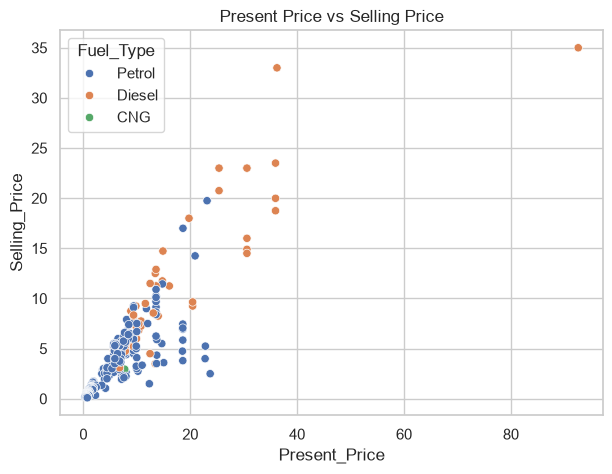

In [8]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type')
plt.title("Present Price vs Selling Price")
plt.show()

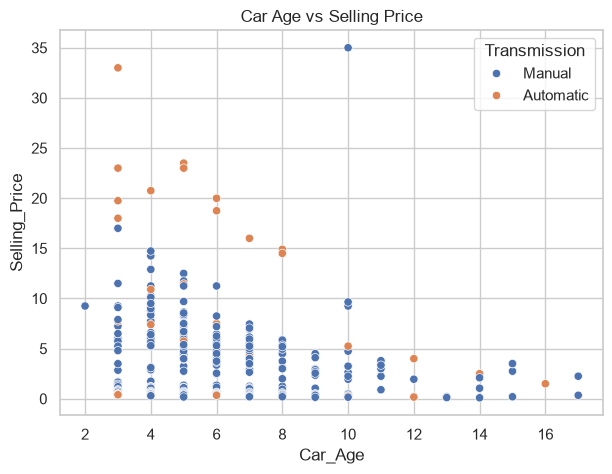

In [9]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Car_Age', y='Selling_Price', hue='Transmission')
plt.title("Car Age vs Selling Price")
plt.show()

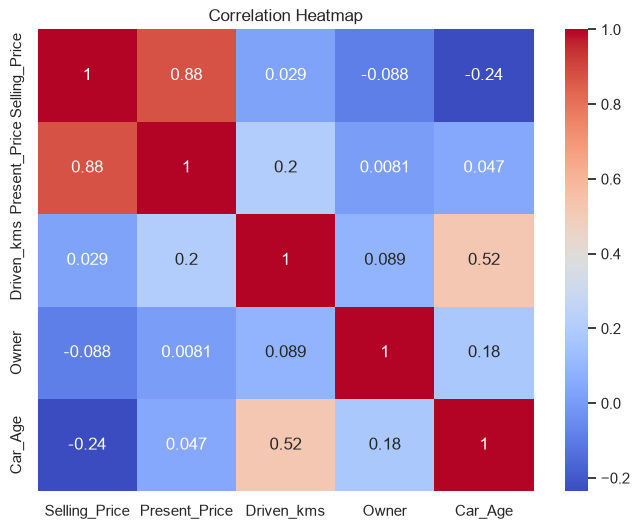

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df_model.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Observation:** `Present_Price` has a strong positive correlation with `Selling_Price` — naturally, more expensive new cars resell for more. `Car_Age` has a negative relationship — older cars sell for less.

## Step 5: Data Preprocessing (Encode Categorical Features)

In [11]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

df_encoded.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


## Step 6: Train/Test Split

In [12]:
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (240, 8)
Test size: (61, 8)


## Step 7: Train Regression Models

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.4f}")

Linear Regression: MAE=1.216, RMSE=1.866, R2=0.8489
Random Forest: MAE=0.649, RMSE=0.977, R2=0.9585


## Step 8: Evaluate the Best Model

In [14]:
results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
Linear Regression,1.216374,1.865838,0.848871
Random Forest,0.649421,0.977369,0.958532


Best model: Random Forest


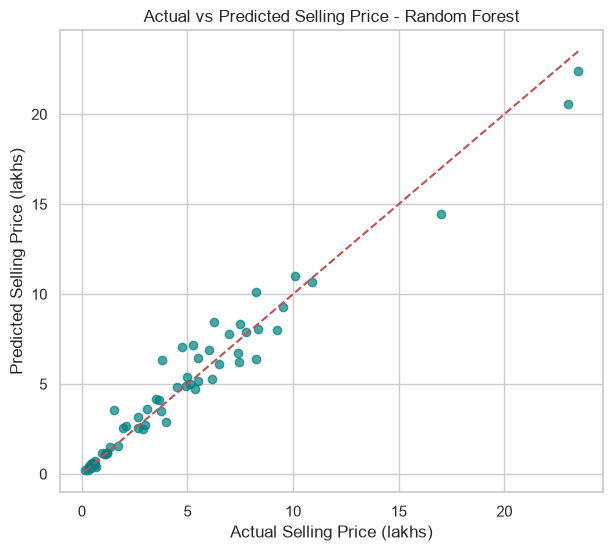

In [15]:
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
print("Best model:", best_model_name)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Selling Price (lakhs)")
plt.ylabel("Predicted Selling Price (lakhs)")
plt.title(f"Actual vs Predicted Selling Price - {best_model_name}")
plt.show()

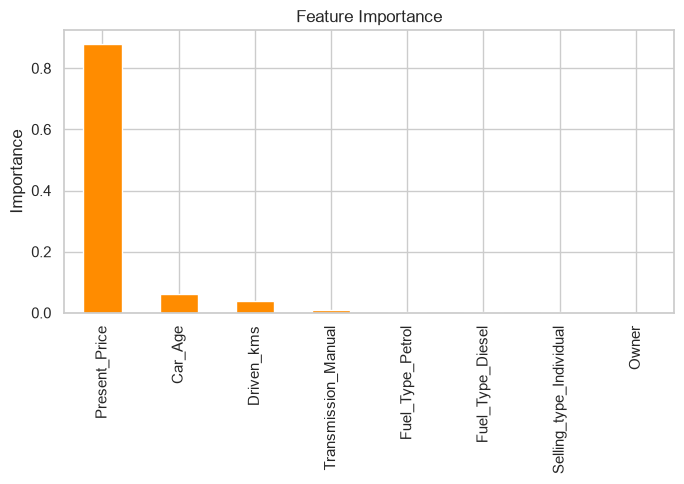

Present_Price              0.879515
Car_Age                    0.061085
Driven_kms                 0.040046
Transmission_Manual        0.009704
Fuel_Type_Petrol           0.003450
Fuel_Type_Diesel           0.003398
Selling_type_Individual    0.002316
Owner                      0.000486
dtype: float64


In [16]:
# Feature importance (only meaningful for tree-based models like Random Forest)
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(7,5))
    importances.plot(kind='bar', color='darkorange')
    plt.title("Feature Importance")
    plt.ylabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importances)

## Conclusion

- **Present_Price** (the car's original/current market price) is the strongest predictor of resale value — makes intuitive sense, as expensive cars retain proportionally higher resale value.
- **Car_Age** and **Driven_kms** negatively affect selling price — older, more-driven cars sell for less.
- **Fuel type and transmission** have a smaller but measurable effect — diesel and automatic cars often resell slightly higher.
- The Random Forest model captures non-linear relationships better than plain Linear Regression, usually giving a higher R² score.

**Real-world application:** A model like this could power an online used-car valuation tool, helping sellers price their car fairly and helping buyers spot overpriced or underpriced listings.

**Next steps (optional improvements):**
- Try encoding `Car_Name`/brand using target encoding instead of dropping it, since brand reputation affects resale value.
- Try hyperparameter tuning (GridSearchCV) on the Random Forest for better accuracy.
- Try Gradient Boosting (XGBoost) for potentially even better performance.
